In [1]:
import pandas as pd

df = pd.read_csv("synthetic_fraud_dataset.csv")
df.head(10)

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0
5,2183,944,97.108625,POS,Clothing,DE,17,0.235399,0.105454,0
6,1919,829,166.209262,Online,Travel,UK,12,0.115906,0.223718,0
7,3479,845,96.512637,Online,Grocery,US,7,0.082250,0.034023,0
8,6796,129,83.338701,QR,Food,DE,16,0.021774,0.279598,0
9,5129,249,89.695731,QR,Grocery,UK,6,0.095353,0.136336,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   amount             10000 non-null  float64
 3   transaction_type   10000 non-null  str    
 4   merchant_category  10000 non-null  str    
 5   country            10000 non-null  str    
 6   hour               10000 non-null  int64  
 7   device_risk_score  10000 non-null  float64
 8   ip_risk_score      10000 non-null  float64
 9   is_fraud           10000 non-null  int64  
dtypes: float64(3), int64(4), str(3)
memory usage: 781.4 KB


In [3]:
df.describe()

,transaction_id,user_id,amount,hour,device_risk_score,ip_risk_score,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,500.058700,178.142763,14.247100,0.183773,0.184669,0.050000
std,2886.89568,288.328495,531.647950,5.347383,0.177381,0.175772,0.217956
min,0.00000,0.000000,1.000000,0.000000,0.000030,0.000009,0.000000
25%,2499.75000,247.000000,65.084753,10.000000,0.075721,0.077762,0.000000
50%,4999.50000,503.000000,101.686510,14.000000,0.156583,0.158290,0.000000
75%,7499.25000,750.250000,138.280872,19.000000,0.234939,0.236968,0.000000
max,9999.00000,999.000000,11628.213881,23.000000,0.998737,0.999603,1.000000


In [4]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [5]:
duplicates = df.duplicated()
print(f"Row with duplicates: {duplicates.sum()}")

Row with duplicates: 0


In [6]:
# hapus kolom
df = df.drop(columns=["transaction_id", "user_id", "is_fraud"])

In [7]:
# encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ["transaction_type", "merchant_category", "country"]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [8]:
# outlier handling IQR
import numpy as np

for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

In [9]:
print(df.shape)

(9487, 7)


In [10]:
# scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

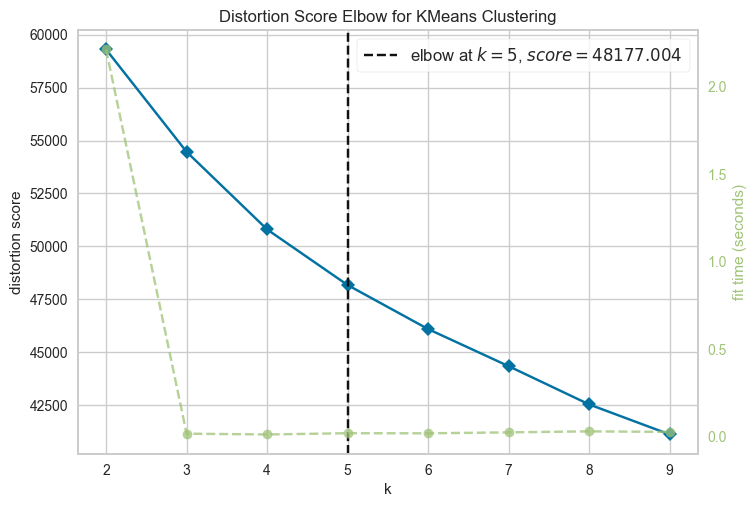

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [11]:
# elbow
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(2, 10), force_model=True)
visualizer.fit(df_scaled)
visualizer.show()

In [12]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(df_scaled)

df["Target"] = clusters

In [13]:
# save model
import joblib

joblib.dump(kmeans, "model_clustering.h5")

['model_clustering.h5']

In [14]:
from sklearn.metrics import silhouette_score

score = silhouette_score(df_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.1074219513298727


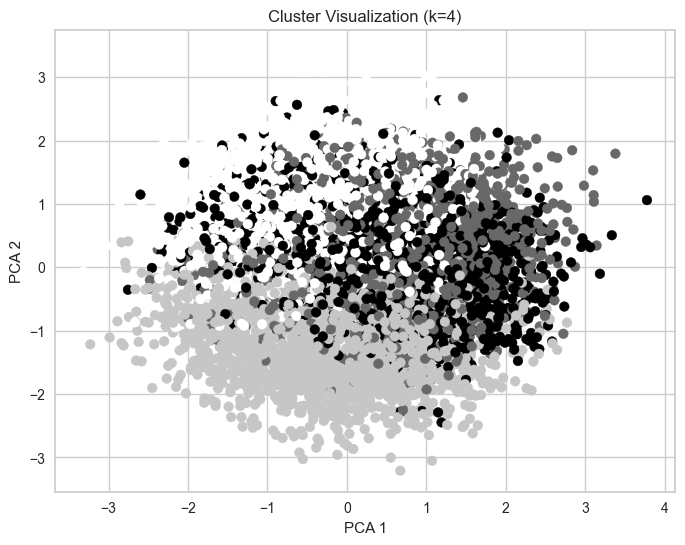

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=clusters)
plt.title("Cluster Visualization (k=4)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [16]:
df.groupby("Target").agg(["mean", "min", "max"])

amount                  transaction_type          \
              mean  min         max             mean min max   
Target                                                         
0       100.280764  1.0  245.851639         2.544124   2   3   
1        92.462104  1.0  242.681129         1.550318   0   3   
2       100.934178  1.0  245.147081         0.441565   0   1   
3       107.042513  1.0  246.307867         1.434547   0   3   

       merchant_category           country  ...           hour          \
                    mean min max      mean  ... max       mean min max   
Target                                      ...                          
0               2.036580   0   4  0.760860  ...   3  14.468221   6  23   
1               0.770670   0   2  4.096895  ...   5  14.185559   6  23   
2               1.983374   0   4  0.762347  ...   3  14.304645   6  23   
3               3.267235   2   4  4.101859  ...   5  14.899303   6  23   

       device_risk_score                     ip_risk_score                      
                    mean       min       max          mean       min       max  
Target                                                                          
0               0.148516  0.000039  0.299926      0.147478  0.000029  0.299847  
1               0.145735  0.000030  0.299939      0.157612  0.000054  0.299993  
2               0.148713  0.000144  0.299998      0.151137  0.000067  0.299933  
3               0.150725  0.000163  0.299878      0.141730  0.000009  0.299867  

[4 rows x 21 columns]

In [17]:
# save data
df.to_csv("data_clustering.csv", index=False)

In [18]:
# PCA model
joblib.dump(pca, "PCA_model_clustering.h5")

['PCA_model_clustering.h5']

In [19]:
df_inverse = pd.DataFrame(scaler.inverse_transform(df_scaled), columns=df.columns[:-1])
df_inverse["Target"] = clusters

df_inverse.to_csv("data_clustering_inverse.csv", index=False)

In [20]:
df.groupby("Target").mean()

,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score
Target,,,,,,,
0,100.280764,2.544124,2.036580,0.760860,14.468221,0.148516,0.147478
1,92.462104,1.550318,0.770670,4.096895,14.185559,0.145735,0.157612
2,100.934178,0.441565,1.983374,0.762347,14.304645,0.148713,0.151137
3,107.042513,1.434547,3.267235,4.101859,14.899303,0.150725,0.141730


<Axes: xlabel='Target', ylabel='amount'>

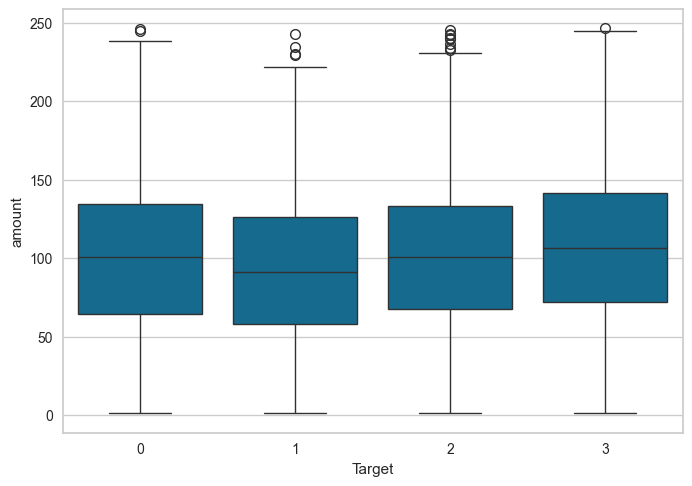

In [21]:
import seaborn as sns

sns.boxplot(x="Target", y="amount", data=df)

In [22]:
df["Target"].value_counts()

Target
1    2673
3    2582
0    2187
2    2045
Name: count, dtype: int64

**Klasifikasi**

In [23]:
X = df.drop(columns=["Target"])
y = df["Target"]

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [26]:
y_pred = model.predict(X_test)

In [27]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       437
           1       0.97      0.99      0.98       535
           2       1.00      0.99      0.99       409
           3       0.98      0.98      0.98       517

    accuracy                           0.99      1898
   macro avg       0.99      0.99      0.99      1898
weighted avg       0.99      0.99      0.99      1898



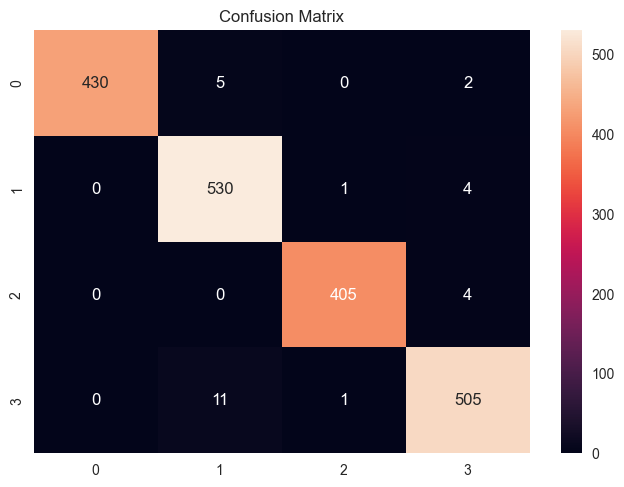

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

Hasil evaluasi menunjukkan akurasi sebesar 100% pada seluruh metrik. Hal ini mengindikasikan bahwa model mampu mengklasifikasikan data dengan sangat baik. Namun, karena label yang digunakan berasal dari hasil clustering (unsupervised learning), maka kemungkinan terjadi kemudahan dalam pemisahan kelas (linearly separable). Oleh karena itu, hasil ini tidak sepenuhnya mencerminkan performa model pada data nyata (real-world scenario), melainkan hanya menunjukkan kemampuan model dalam mereplikasi hasil clustering.

<Axes: >

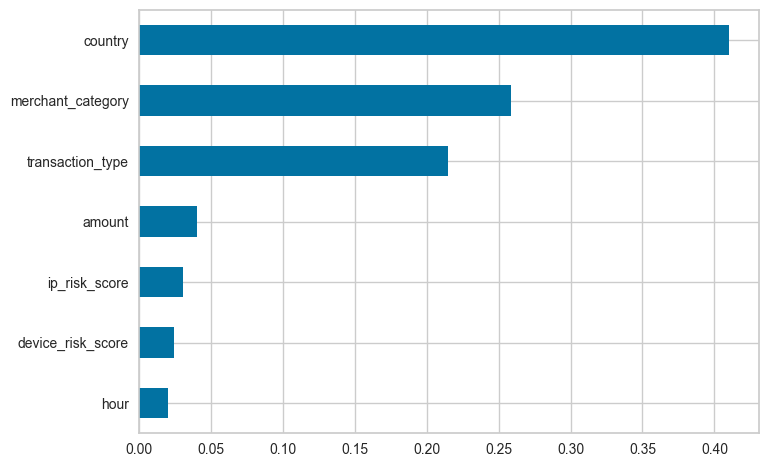

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

import pandas as pd

feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind="barh")